# Dataset
[ISIC 2028](https://challenge.isic-archive.com/data/#2018)

In [6]:
import os
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

# Exploratory Data Analysis

In [7]:
root = '/gpfs01/berens/data/data/medical_imaging/Dermoscopy/ISIC_2018/Task3/'

In [9]:
df = pd.read_csv(os.path.join(root, 'Training_GroundTruth.csv'))
print(df.shape)
df.head()

(10015, 9)


,image,MEL,NV,BCC,AKIEC,BKL,DF,VASC,label
0,ISIC_0024306,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1
1,ISIC_0024307,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1
2,ISIC_0024308,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1
3,ISIC_0024309,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1
4,ISIC_0024310,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [10]:
## Checking for missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   image   10015 non-null  str    
 1   MEL     10015 non-null  float64
 2   NV      10015 non-null  float64
 3   BCC     10015 non-null  float64
 4   AKIEC   10015 non-null  float64
 5   BKL     10015 non-null  float64
 6   DF      10015 non-null  float64
 7   VASC    10015 non-null  float64
 8   label   10015 non-null  int64  
dtypes: float64(7), int64(1), str(1)
memory usage: 704.3 KB


## Plot class distribution

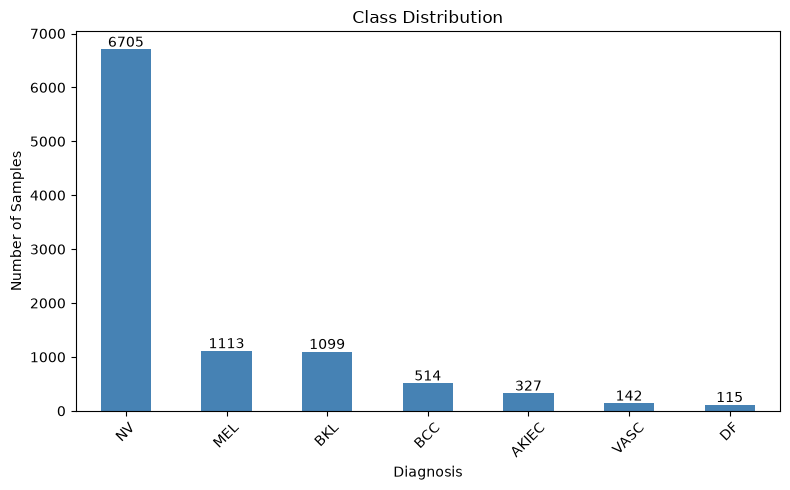

In [11]:
class_cols = ['MEL', 'NV', 'BCC', 'AKIEC', 'BKL', 'DF', 'VASC']
counts = df[class_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
counts.plot(kind='bar', color='steelblue')
plt.title('Class Distribution')
plt.xlabel('Diagnosis')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45)

for i, v in enumerate(counts):
    plt.text(i, v + 50, str(int(v)), ha='center')
    
plt.tight_layout()
plt.show()

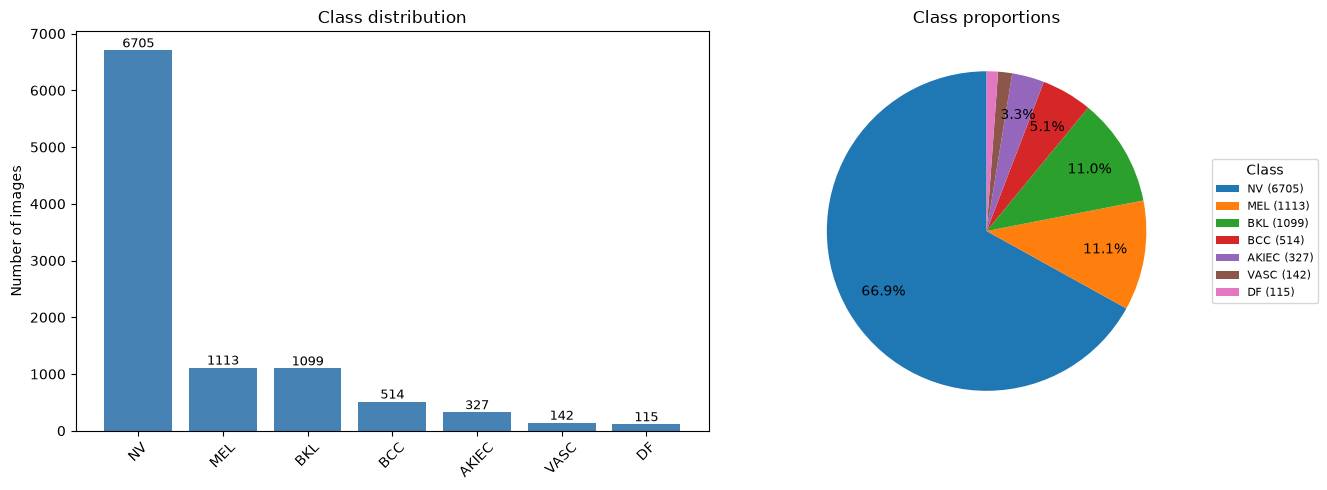

In [12]:
# --- Log-scale bar chart ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Standard bar chart ---
bars = axes[0].bar(counts.index, counts.values, color='steelblue')
axes[0].set_ylabel('Number of images')
axes[0].set_title('Class distribution')
axes[0].tick_params(axis='x', rotation=45)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val, int(val), ha='center', va='bottom', fontsize=9)

# --- Pie chart, decluttered ---
colors = plt.cm.tab10.colors
wedges, _, autotexts = axes[1].pie(
    counts.values,
    autopct=lambda p: f'{p:.1f}%' if p > 3 else '',  # hide tiny labels
    startangle=90,
    colors=colors,
    pctdistance=0.75,
)
axes[1].set_title('Class proportions')
axes[1].legend(
    wedges, [f'{name} ({int(val)})' for name, val in zip(counts.index, counts.values)],
    title='Class',
    loc='center left',
    bbox_to_anchor=(1.05, 0.5),
    fontsize=8,
)

plt.tight_layout()
plt.show()

In [32]:
counts / len(df) * 100

NV       66.949576
MEL      11.113330
BKL      10.973540
BCC       5.132302
AKIEC     3.265102
VASC      1.417873
DF        1.148278
dtype: float64

## Ploting sample examples

In [13]:
# path to the folder containing the images
img_dir = os.path.join(root, 'Training_Input') 
img_ext = '.jpg' 

In [14]:
class_cols = ['MEL', 'NV', 'BCC', 'AKIEC', 'BKL', 'DF', 'VASC']
n_samples = 4

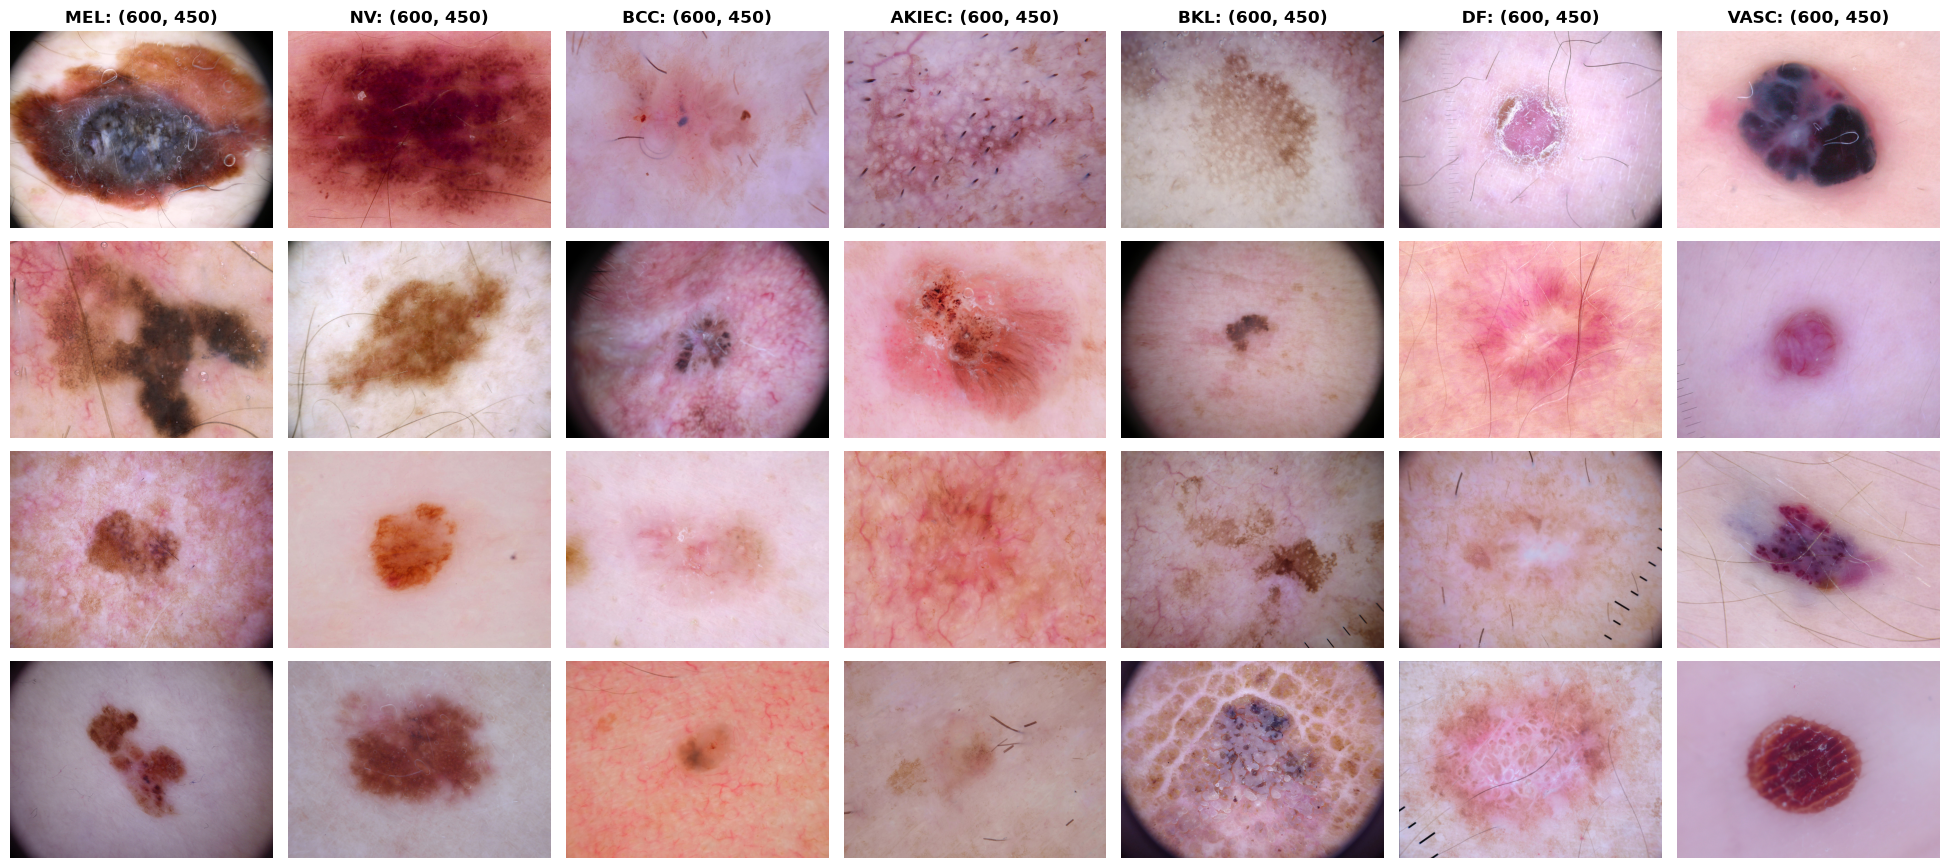

In [15]:
fig, axes = plt.subplots(n_samples, len(class_cols), figsize=(2.8*len(class_cols), 2.2*n_samples))

for col_idx, cls in enumerate(class_cols):
    # get image ids belonging to this class
    cls_df = df[df[cls] == 1.0]
    sample_ids = cls_df['image'].sample(n=n_samples, random_state=42).values

    for row_idx, img_id in enumerate(sample_ids):
        img_path = os.path.join(img_dir, img_id + img_ext)
        img = Image.open(img_path)

        ax = axes[row_idx, col_idx]
        ax.imshow(img)
        ax.axis('off')

        if row_idx == 0:
            ax.set_title(f'{cls}: {img.size}', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## Question
- What else?

## ToDo by Team
- t-SNE or UMAP on CNN feature embeddings (e.g., from a pretrained ResNet) colored by class — helps visually assess how separable classes are before training. It can also reveal potential outliers or mislabelled images
- Color/intensity distribution per class (mean RGB histograms). Do some classes have distinct pigmentation?
- Mean brightness/contrast per class (histograms or box plots). How much variation is there in intensity across the image? How light or dark an image is overall?  Might be useful for deciding on normalization.